# Linear Regression

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import pandas as pd

data = {
    "YearsExperience": [
        1.1, 1.3, 1.5, 2.0, 2.2, 2.9, 3.0, 3.2,
        3.7, 3.9, 4.0, 4.5, 4.9, 5.1, 5.3,
        5.9, 6.0, 6.8, 7.1, 7.9, 8.2, 8.7,
        9.0, 9.5, 9.6, 10.3, 10.5
    ],
    "Salary": [
        39343, 46205, 37731, 43525, 39891, 56642,
        60150, 54445, 57189, 63218, 55794, 61111,
        67938, 66029, 83088, 81363, 93940, 91738,
        98273, 101302, 113812, 109431, 105582,
        116969, 112635, 122391, 121872
    ]
}

df = pd.DataFrame(data)

df.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [4]:
df.shape

(27, 2)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  27 non-null     float64
 1   Salary           27 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 564.0 bytes


In [6]:
df.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

In [8]:
df.describe()

,YearsExperience,Salary
count,27.000000,27.000000
mean,5.485185,77837.296296
std,2.942357,28318.078576
min,1.100000,37731.000000
25%,3.100000,56218.000000
50%,5.100000,67938.000000
75%,8.050000,103442.000000
max,10.500000,122391.000000


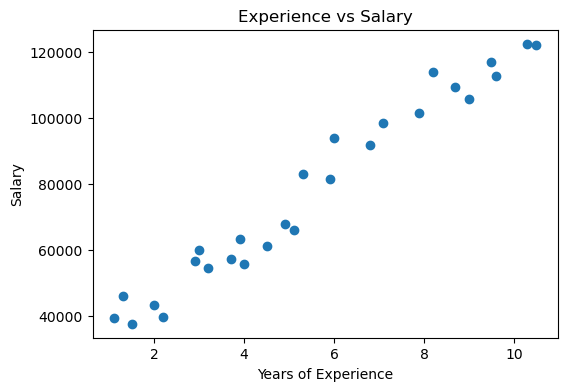

In [9]:
plt.figure(figsize=(6,4))
plt.scatter(df["YearsExperience"], df["Salary"])
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Experience vs Salary")
plt.show()

In [10]:
X = df[["YearsExperience"]]
y = df["Salary"]

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [13]:
print(model.intercept_)
print(model.coef_)

27102.30022556121
[9381.81416402]


In [14]:
y_pred = model.predict(X_test)

In [15]:
prediction = pd.DataFrame({
    "Actual Salary": y_test,
    "Predicted Salary": y_pred
})

prediction.head()

,Actual Salary,Predicted Salary
8,57189,61815.012632
13,66029,74949.552462
9,63218,63691.375465
21,109431,108724.083453
0,39343,37422.295806


In [16]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print(mae)

4142.837544149068


In [17]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)

print(mse)

28797411.268674552


In [18]:
rmse = np.sqrt(mse)

print(rmse)

5366.321949778503


In [19]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print(r2)

0.9361501631773932


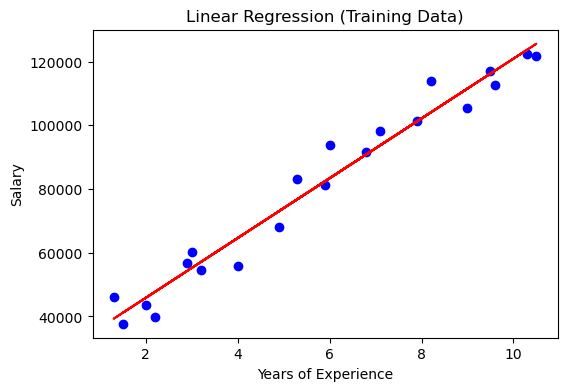

In [20]:
plt.figure(figsize=(6,4))

plt.scatter(X_train, y_train, color="blue")
plt.plot(X_train, model.predict(X_train), color="red")

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Linear Regression (Training Data)")

plt.show()

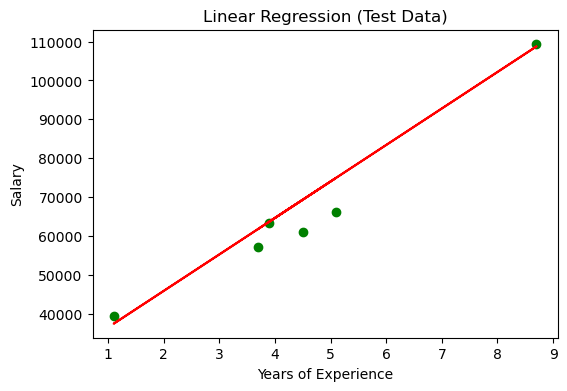

In [21]:
plt.figure(figsize=(6,4))

plt.scatter(X_test, y_test, color="green")
plt.plot(X_test, model.predict(X_test), color="red")

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Linear Regression (Test Data)")

plt.show()

In [23]:
new_data = pd.DataFrame({
    "YearsExperience": [7]
})

salary = model.predict(new_data)

print("Predicted Salary:", salary[0])

Predicted Salary: 92774.9993737239


## Multi-collinearity
Multicollinearity is a problem in Multiple Linear Regression where two or more independent variables (features) are highly correlated with each other. This means they contain similar information, making it difficult for the model to determine the individual effect of each feature on the target variable.  
How to Handle Multicollinearity:

Remove one of the highly correlated features.  
Combine correlated features into a single feature.  
Use feature selection techniques.  

To solve a part from dependent feature which all features are highly corelated like mor than 90% we will write block of code take those feature and drop that code this work if we have small feature.  
For more features we have we will solve we take those features and appply ridge or lasso regrresion.  

## Bias and Variance  
Bias is the error from making wrong assumptions (leading to underfitting).  
while variance is the error from being too sensitive to changes in training data (leading to overfitting).  
Balancing them is key to minimizing total prediction error on new data.  

Bias:  
->Error from a model being too simple.  
->Misses true patterns in the data.  
->Causes underfitting (poor performance on both training and test sets).  
->Example: Using a straight linear regression line for a curved, non-linear pattern.  
Variance:  
->Error from a model being too complex or flexible.  
->Captures random noise instead of the real trend.  
->Causes overfitting (great on training data, poor on unseen test data).  
->Example: Fitting a wildly wiggly, high-degree polynomial line through every single training point.  
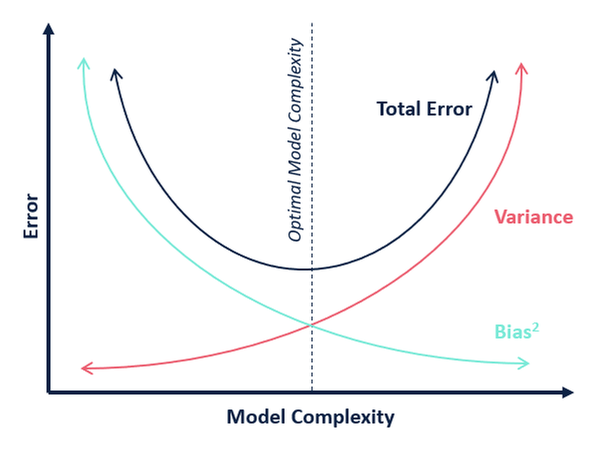 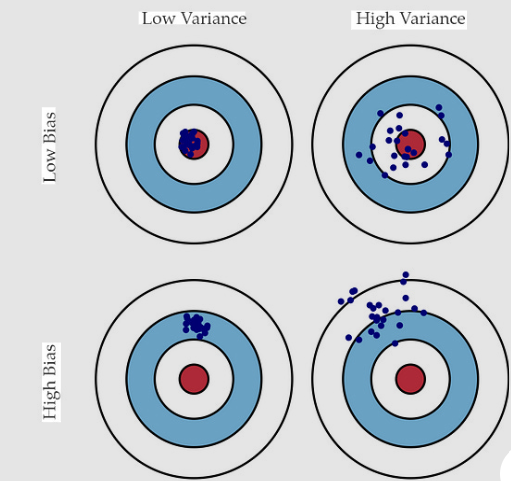

## Regularization  
Regularization in regression is a technique used to prevent overfitting by adding a penalty for model complexity, most commonly through Ridge (L2) regression, Lasso (L1) regression, and Elastic Net. It shrinks coefficient weights toward zero, stabilizes high-dimensional data, and improves predictions on unseen data.  
Is used to train some data there is a chance the model get overfit where regularization helps to sort overfitting problem by restricting degree of freedom of a given equation.   

Suppose you train a model with many features.  
Without regularization: The model may fit the training data too closely (overfitting).  
With regularization: The model keeps the coefficients smaller, making it simpler and more robust.  

### Ridge Regression  
Ridge Regression (L2): Adds the squared magnitude of coefficients as a penalty. It shrinks weights evenly and handles multicollinearity well without removing features entirely.  
Ridge Regression is a version of linear regression that adds an L2 penalty to control large coefficient values. While Linear Regression only minimizes prediction error, it can become unstable when features are highly correlated.  
Ridge solves this by shrinking coefficients making the model more stable and reducing overfitting.  

$$
\text{Cost} = RSS + \lambda \sum_{i=1}^{n}\beta_i^2
$$  
Characteristics:  

Shrinks coefficients toward zero.  
Does not make coefficients exactly zero.  
Keeps all features in the model.  
Works well when there is multicollinearity.  

### Lasso Regression  
Lasso Regression (L1): Adds the absolute value of coefficients as a penalty. It can drive weak feature coefficients completely to zero, performing automated feature selection.  
Uses L1 regularization to reduce overfitting  
Encourages sparse models (zero coefficients )  
Automatically performs feature selectio- n Useful for high‑dimensional datasets  
$$
\text{Cost} = RSS + \lambda \sum_{i=1}^{n}|\beta_i|
$$
Characteristics:

Shrinks coefficients.  
Can make some coefficients exactly 0.  
Automatically performs feature selection by removing less important features.  

### Difference between Ridge and Lasso  
Ridge regression shrinks the coefficients for those predictors which contribute very less in the model but have huge weights, very close to zero. But it never makes them exactly zero. Thus, the final model will still contain all those predictors, though with less weights. This doesn't help in interpreting the model very well.  

In Lasso, the L1 penalty does reduce some coefficients exactly to zero when we use a sufficiently large tuning parameter.  
In addition to regularizing, lasso also performs feature selection.   


## Elastic Net  
Elastic Net is middle between Ridge Regression and Lasso Regression. It is a simple mix of both Ridge and Lasso Regularization terms and can control mix ratio.  
$$
J(\beta)=\sum_{i=1}^{n}(y_i-\hat{y}_i)^2
+\lambda_1\sum_{j=1}^{p}|\beta_j|
+\lambda_2\sum_{j=1}^{p}\beta_j^2
$$
Characteristics:  

Performs feature selection like Lasso.    
Handles multicollinearity like Ridge.  
Useful when there are many correlated features.  

## Multiple Linear Regression  
It is an extension of simple linear regression where we use two or more independent variables (features) to predict a single dependent variable (target).  
$$
\hat{y} = b_0 + b_1x_1 + b_2x_2 + b_3x_3 + ... + b_nx_n
$$
Where:  

y = predicted output (target)   
b0 = intercept  
b1, b2, b3 = coefficients  
x1, x2, x3 = input features

## Polynomial Regression   
It is a supervised machine learning algorithm used to model non-linear relationships by fitting a curved line to your data points. While a simple linear regression fits a straight line, polynomial regression transforms your input features into higher-degree powers (like \(x^2, x^3\)) to capture complex curves and trends.  
$$
\hat{y}=b_0+b_1x+b_2x^2+b_3x^3+...+b_nx^n
$$
Where:  
y: The target prediction (dependent variable).  
x: The original input feature (independent variable).  
b0: The bias or intercept term.  
b1,b2,....bn: The weights/coefficients assigned to each power.  
n: The degree of the polynomial, which determines the complexity of the curve.  


Example:  
$$
Salary=b_0+b_1x+b_2x^2
$$
x= experience
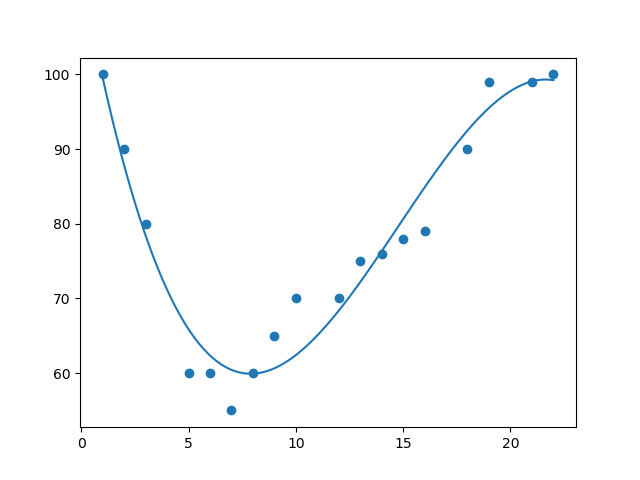